# **MACHINE** **LEARNING**


TASK 1 : MOVIE GENRE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/train_data.txt",delimiter=":::",header=None)

/tmp/ipykernel_423/2947902000.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df=pd.read_csv("/content/train_data.txt",delimiter=":::",header=None)


In [3]:
df.head()

,0,1,2,3
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [4]:
df.reset_index(inplace=True)

In [5]:
df.drop(columns=0,inplace=True)

In [6]:
df.rename(columns={1:'title',2:'genres',3:'description'},inplace=True)

In [7]:
df.shape

(20753, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20753 entries, 0 to 20752
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   index        20753 non-null  int64 
 1   title        20753 non-null  object
 2   genres       20753 non-null  object
 3   description  20753 non-null  object
dtypes: int64(1), object(3)
memory usage: 648.7+ KB


In [9]:
df.isnull().sum()

,0
index,0
title,0
genres,0
description,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head()

,index,title,genres,description
0,0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,1,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [12]:
df['genres'].value_counts()

,count
genres,
drama,5187
documentary,4995
comedy,2837
short,1997
horror,821
thriller,615
action,495
western,395
reality-tv,352


In [13]:
df.head()

,index,title,genres,description
0,0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,1,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [14]:
df['year'] = df['title'].str.split('(').str.get(1).str.split(")").str.get(0)

In [15]:
df['title'] = df['title'].str.split('(').str.get(0)

In [16]:
df.head()

,index,title,genres,description,year
0,0,Oscar et la dame rose,drama,Listening in to a conversation between his do...,2009
1,1,Cupid,thriller,A brother and sister with a past incestuous r...,1997
2,2,"Young, Wild and Wonderful",adult,As the bus empties the students for their fie...,1980
3,3,The Secret Sin,drama,To help their unemployed father make ends mee...,1915
4,4,The Unrecovered,drama,The film's title refers not only to the un-re...,2007


In [17]:
df['title'] = df['title'].apply(lambda x:x.lower())
df['description'] = df['description'].apply(lambda x: x.lower())

In [18]:
df.head()

,index,title,genres,description,year
0,0,oscar et la dame rose,drama,listening in to a conversation between his do...,2009
1,1,cupid,thriller,a brother and sister with a past incestuous r...,1997
2,2,"young, wild and wonderful",adult,as the bus empties the students for their fie...,1980
3,3,the secret sin,drama,to help their unemployed father make ends mee...,1915
4,4,the unrecovered,drama,the film's title refers not only to the un-re...,2007


In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['genres'] = le.fit_transform(df['genres'])

In [20]:
cls = le.classes_
processed = le.transform(cls)
for i in range(len(cls)):
    print(cls[i]," ----- ",processed[i])

 action   -----  0
 adult   -----  1
 adventure   -----  2
 animation   -----  3
 biography   -----  4
 comedy   -----  5
 crime   -----  6
 documentary   -----  7
 drama   -----  8
 family   -----  9
 fantasy   -----  10
 game-show   -----  11
 history   -----  12
 horror   -----  13
 music   -----  14
 musical   -----  15
 mystery   -----  16
 news   -----  17
 reality-tv   -----  18
 romance   -----  19
 sci-fi   -----  20
 short   -----  21
 sport   -----  22
 talk-show   -----  23
 thriller   -----  24
 war   -----  25
 western   -----  26


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [22]:
df.head()

,index,title,genres,description,year
0,0,oscar et la dame rose,8,listening in to a conversation between his do...,2009
1,1,cupid,24,a brother and sister with a past incestuous r...,1997
2,2,"young, wild and wonderful",1,as the bus empties the students for their fie...,1980
3,3,the secret sin,8,to help their unemployed father make ends mee...,1915
4,4,the unrecovered,8,the film's title refers not only to the un-re...,2007


In [23]:
df['tags'] = df['description'] + df['title']

In [24]:
df['tags'][0]

' listening in to a conversation between his doctor and parents, 10-year-old oscar learns what nobody has the courage to tell him. he only has a few weeks to live. furious, he refuses to speak to anyone except straight-talking rose, the lady in pink he meets on the hospital stairs. as christmas approaches, rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow oscar to live life and love to the full, in the company of his friends pop corn, einstein, bacon and childhood sweetheart peggy blue. oscar et la dame rose '

In [25]:
x = df['tags'].values
y = df['genres'].values

In [26]:
x_transformed = tfidf.fit_transform(x).toarray()

In [27]:
x_transformed.shape

(20753, 3000)

In [28]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_transformed,y,test_size=0.2,shuffle=True)

In [30]:
gb.fit(x_train,y_train)

GaussianNB()

In [31]:
from sklearn.metrics import accuracy_score,recall_score,precision_score
y_pred = gb.predict(x_test)
print("Accuracy : ",accuracy_score(y_true=y_test,y_pred=y_pred))

Accuracy :  0.297036858588292


In [32]:
mnb.fit(x_train,y_train)
mnb_pred = mnb.predict(x_test)
print("Accuracy : ",accuracy_score(y_true=y_test,y_pred=mnb_pred))

Accuracy :  0.4861479161647796


In [33]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)
print("Accuracy : ",accuracy_score(y_true=y_test,y_pred=lr_pred))

Accuracy :  0.5552878824379668


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
df.head()

,index,title,genres,description,year,tags
0,0,oscar et la dame rose,8,listening in to a conversation between his do...,2009,listening in to a conversation between his do...
1,1,cupid,24,a brother and sister with a past incestuous r...,1997,a brother and sister with a past incestuous r...
2,2,"young, wild and wonderful",1,as the bus empties the students for their fie...,1980,as the bus empties the students for their fie...
3,3,the secret sin,8,to help their unemployed father make ends mee...,1915,to help their unemployed father make ends mee...
4,4,the unrecovered,8,the film's title refers not only to the un-re...,2007,the film's title refers not only to the un-re...


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['title']).toarray()
y = df['genres'].values

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.32642736689954227


In [42]:
print("/content/description.txt", classification_report(y_test, y_pred))

/content/description.txt               precision    recall  f1-score   support

           0       0.00      0.00      0.00        99
           1       0.00      0.00      0.00        49
           2       0.00      0.00      0.00        56
           3       0.00      0.00      0.00        31
           4       0.00      0.00      0.00        25
           5       0.27      0.14      0.18       568
           6       0.00      0.00      0.00        42
           7       0.37      0.51      0.43      1003
           8       0.31      0.69      0.43      1039
           9       0.00      0.00      0.00        61
          10       0.00      0.00      0.00        30
          11       0.00      0.00      0.00        12
          12       0.00      0.00      0.00        13
          13       0.50      0.12      0.20       154
          14       0.64      0.11      0.18        65
          15       0.00      0.00      0.00        21
          16       0.00      0.00      0.00        24
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
import numpy as np

labels = sorted(np.unique(y_test))

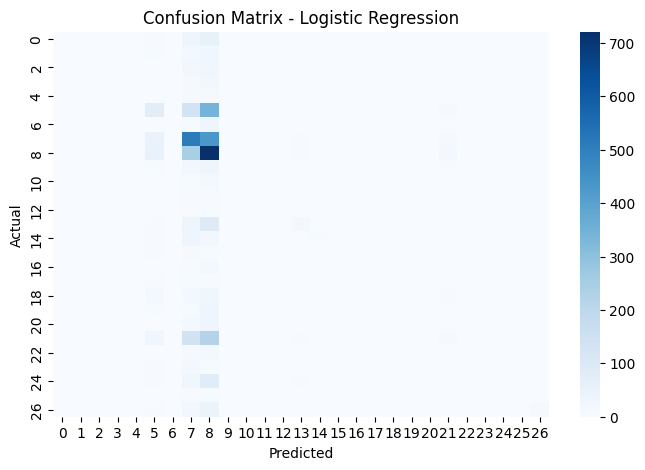

In [44]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=False, cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

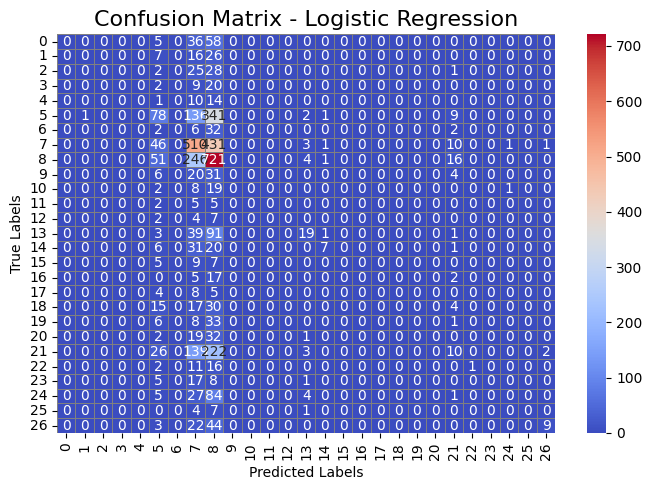

In [45]:
plt.figure(figsize=(7,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='coolwarm',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5,
            linecolor='gray')

plt.title("Confusion Matrix - Logistic Regression", fontsize=16)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.show()

In [46]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.3175138520838352


In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.33556596320236376


In [48]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv  =3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}


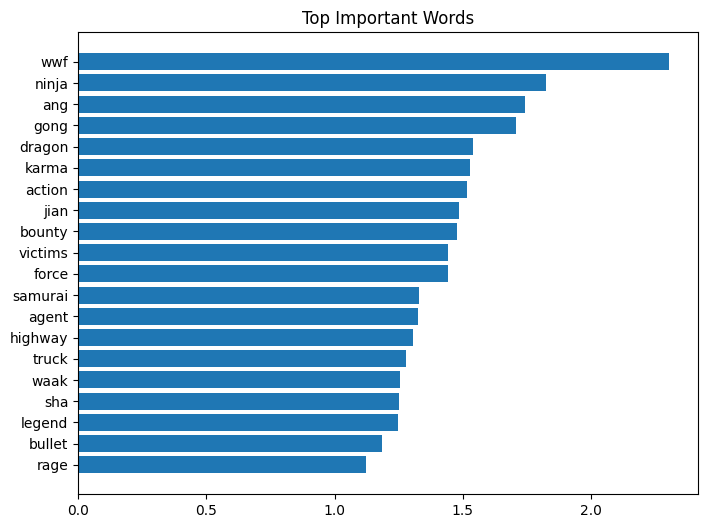

In [49]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_features = np.argsort(coefficients)[-20:]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_features], coefficients[top_features])
plt.title("Top Important Words")
plt.show()